# 02 — Curadoria, anonimização e retenção

**Entrada:** `../data/corpus_escopo.parquet` (saída do `01`).
**Saída:** `../data/corpus_curado.parquet`.

Três coisas acontecem aqui, nesta ordem:

1. **Filtros de qualidade** — corte de tamanho derivado da distribuição, não de números redondos.
2. **Verificação de anonimização** — a fonte já é anônima; aqui medimos o resíduo.
3. **Retenção de duplicatas** — clusteriza near-duplicatas e decide quantas preservar.

Notebook barato: não faz chamada de API. Pode ser re-executado à vontade.

> **O que o MedPT já fez por nós**, segundo o dataset card: normalização (HTML, URLs,
> caracteres especiais), deduplicação por texto de Q&A, e filtro de respostas
> (removidas as com menos de 10 tokens e as com mais de 1000). Então a distribuição
> que recebemos já vem truncada, e nossos cortes atuam sobre o que sobrou.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

DATA = Path.cwd().parent / "data"
CORPUS_ESCOPO = DATA / "corpus_escopo.parquet"
CORPUS_CURADO = DATA / "corpus_curado.parquet"
SEED = 42

corpus = pd.read_parquet(CORPUS_ESCOPO)
print(f"{len(corpus):,} linhas | {corpus['condition'].nunique()} condições")
corpus.head(3)

21,967 linhas | 662 condições


,id,question,answer,condition,medical_specialty,question_type
0,1612,Meu filho apresentou bruxismo noturno e após u...,"Não, não é normal, o leve para avaliação com p...",Bruxismo,Pediatra,Diagnóstico
1,1613,Meu filho apresentou bruxismo noturno e após u...,É possível que o bruxismo diurno esteja relaci...,Bruxismo,Pediatra,Diagnóstico
2,1701,Meu bebê tem 6 meses tem 4 dentes ele fica rig...,"Sim, a primeira consulta com dentista deve ser...",Bruxismo,Pediatra,Escolha de profissionais de saúde


## Filtro de tamanho

A versão anterior calculava `filtrado` e nunca usava: o `corpus` seguia sem o corte para
o dedup e para o split. O `print` mostrava os dois números e dava a impressão de ter
funcionado.

Além de aplicar o resultado, os limiares deixam de ser números redondos (`100`, `3000`,
`20`) e passam a sair de percentis da distribuição real. O corte é uma decisão sobre o
que é ruído; vale olhar o que ele descarta antes de aceitá-lo.

Lembrando que o MedPT já removeu respostas com menos de 10 e mais de 1000 tokens. A cauda
que sobrou é mais curta do que seria em dado bruto, então espere um corte modesto — e
desconfie se ele vier grande.

In [2]:
corpus["tam_q"] = corpus["question"].str.len()
corpus["tam_a"] = corpus["answer"].str.len()

corpus[["tam_q", "tam_a"]].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

,tam_q,tam_a
count,21967.000000,21967.000000
mean,161.751445,423.172031
std,93.533278,373.522793
min,18.000000,25.000000
1%,42.000000,45.000000
5%,54.000000,68.300000
25%,91.000000,154.000000
50%,139.000000,285.000000
75%,217.000000,592.000000
95%,305.000000,1142.000000


In [3]:
# Botoes desta etapa: os percentis. Cortar a cauda de baixo remove truncado e vazio;
# cortar a de cima remove respostas que viraram artigo e desbalanceiam o treino.
P_INF_RESP, P_SUP_RESP, P_INF_PERG = 0.01, 0.99, 0.01

lim_a_inf = corpus["tam_a"].quantile(P_INF_RESP)
lim_a_sup = corpus["tam_a"].quantile(P_SUP_RESP)
lim_q_inf = corpus["tam_q"].quantile(P_INF_PERG)

print(f"resposta: [{lim_a_inf:.0f}, {lim_a_sup:.0f}] chars | pergunta: >= {lim_q_inf:.0f} chars")

manter = (
    corpus["tam_a"].between(lim_a_inf, lim_a_sup)
    & (corpus["tam_q"] >= lim_q_inf)
)
descartados = corpus[~manter]
print(f"{len(corpus):,} → {manter.sum():,}  ({len(descartados):,} descartados)")

resposta: [45, 1599] chars | pergunta: >= 42 chars
21,967 → 21,340  (627 descartados)


In [4]:
# Conferir que o descartado e lixo e nao sinal, antes de aceitar o corte.
for rotulo, subset in [
    ("RESPOSTA CURTA DEMAIS", descartados[descartados["tam_a"] < lim_a_inf]),
    ("RESPOSTA LONGA DEMAIS", descartados[descartados["tam_a"] > lim_a_sup]),
    ("PERGUNTA CURTA DEMAIS", descartados[descartados["tam_q"] < lim_q_inf]),
]:
    print(f"\n=== {rotulo} ({len(subset):,}) ===")
    for r in subset.head(5).itertuples():
        print(f"  P({r.tam_q}): {str(r.question)[:110]}")
        print(f"  R({r.tam_a}): {str(r.answer)[:110]}\n")


=== RESPOSTA CURTA DEMAIS (205) ===
  P(74): Na minha transvaginal mostrou que meu endometrio tem 0,3cm,oque significa.
  R(33): Que está normal( endométrioFino )

  P(87): Estou tomando dienogeste a 1 mês minha menstruação veio pouquinho e só 3 dias é normal?
  R(38): Sim. É normal. Pode inclusive não vir.

  P(134): Tomo dienogeste há 2 anos ,fiz ultrassom transvaginal e não apresentou nenhum sinal da endometriose, posso par
  R(44): Sim. E ir acompanhando o seu fluxo menstrual

  P(82): Olá,uso o desogestrel á 5 anos e hoje comecei a sangrar derrapante,o que pode ser?
  R(41): Não sei o que é sangramento derrapante...

  P(136): Fui Picada por uma abelha estou gravida 6 meses mas tirei o ferao , está apenas doendo e um pouco enchado , po
  R(34): Olá. Tudo bem? Não irá prejudicar.


=== RESPOSTA LONGA DEMAIS (219) ===
  P(116): Depois de quanto tempo de ter feito uma cirurgia de endometriose, preciso refazer os exames? Ultrassom, resson
  R(2288): Após uma cirurgia de endometriose,

In [5]:
corpus = corpus[manter].copy()
antes = len(corpus)
corpus = corpus.drop_duplicates(subset=["question", "answer"])
print(f"dedup exato: {antes:,} → {len(corpus):,}")

dedup exato: 21,340 → 21,340


## Verificação de anonimização

**A fonte já é anônima.** O card do MedPT afirma que as perguntas vêm do Doctoralia sem
atribuição de identidade: *"All questions are completely anonymous, ensuring the privacy
and confidentiality of the users."* Não há, portanto, um passo de de-identificação a fazer.

O que fazemos aqui é **verificar**, por dois motivos:

1. Anonimato de conta não é o mesmo que texto limpo. O paciente pode se autoidentificar no
   corpo da pergunta — "meu nome é X", "tenho 32 anos, moro em Y" — e isso sobrevive a um
   pipeline que só remove atribuição de autoria.
2. A fase cobra a técnica como entregável. Uma verificação que mede e reporta o resíduo
   atende o requisito sem fingir um problema que a fonte já resolveu.

Se a contagem vier próxima de zero, **esse é o resultado** e vai assim para o relatório.

Os padrões são conservadores de propósito: um regex de telefone frouxo comeria valores
clínicos (`beta hCG 21888`, `38 semanas`), o que seria pior que não fazer nada.

In [6]:
import re

PADROES = {
    "[CPF]":      re.compile(r"\b\d{3}\.\d{3}\.\d{3}-\d{2}\b|\b\d{11}\b(?!\d)"),
    "[CNS]":      re.compile(r"\b\d{3}\s?\d{4}\s?\d{4}\s?\d{4}\b"),
    "[EMAIL]":    re.compile(r"\b[\w.+-]+@[\w-]+\.[\w.]+\b"),
    "[TELEFONE]": re.compile(r"\(?\b\d{2}\)?[\s.-]?9?\d{4}[\s.-]\d{4}\b"),
    "[CEP]":      re.compile(r"\b\d{5}-\d{3}\b"),
    "[DATA]":     re.compile(r"\b\d{1,2}[/\-]\d{1,2}[/\-]\d{2,4}\b"),
    "[URL]":      re.compile(r"https?://\S+|\bwww\.\S+"),
    "[NOME]":     re.compile(r"\b(?:Dr|Dra|Sr|Sra)\.?\s+[A-ZÁÂÃÀÉÊÍÓÔÕÚÇ][a-záâãàéêíóôõúç]+(?:\s+[A-ZÁÂÃÀÉÊÍÓÔÕÚÇ][a-záâãàéêíóôõúç]+)*"),
    "[NOME]_2":   re.compile(r"\b(?:meu nome (?:é|e)|me chamo|sou (?:a|o))\s+[A-ZÁÂÃÀÉÊÍÓÔÕÚÇ][a-záâãàéêíóôõúç]+"),
}

# Retorna (texto_limpo, {rotulo: n_ocorrencias}).
def anonimiza(texto):
    if not isinstance(texto, str):
        return texto, {}
    contagem = {}
    for rotulo, padrao in PADROES.items():
        marcador = rotulo.split("_")[0]
        texto, n = padrao.subn(marcador, texto)
        if n:
            contagem[marcador] = contagem.get(marcador, 0) + n
    return texto, contagem

In [7]:
from collections import Counter

total = Counter()
linhas_afetadas = set()

for coluna in ("question", "answer"):
    limpos = []
    for pos, texto in enumerate(corpus[coluna]):
        limpo, cont = anonimiza(texto)
        limpos.append(limpo)
        if cont:
            total.update(cont)
            linhas_afetadas.add(pos)
    corpus[coluna] = limpos

print(f"Verificação sobre {len(corpus):,} linhas × 2 campos\n")
if total:
    for rotulo, n in total.most_common():
        print(f"  {rotulo:<12} {n:,}")
    print(f"\n{sum(total.values()):,} ocorrências em {len(linhas_afetadas):,} linhas "
          f"({len(linhas_afetadas)/len(corpus):.2%} do corpus)")
else:
    print("  nenhuma ocorrência — consistente com a fonte já ser anônima")

Verificação sobre 21,340 linhas × 2 campos

  [NOME]       228
  [DATA]       1

229 ocorrências em 228 linhas (1.07% do corpus)


In [17]:
# Auditoria: linhas que ainda parecem conter nome proprio nao capturado.
# Serve para dimensionar o residuo e declarar a limitacao no relatorio.
suspeita = re.compile(r"(?<![.!?]\s)(?<!^)\b[A-ZÁÂÃÀÉÊÍÓÔÕÚÇ][a-záâãàéêíóôõúç]{2,}\b")

amostra = corpus.sample(min(300, len(corpus)), random_state=SEED)
com_suspeita = [
    (r.question, suspeita.findall(str(r.question)))
    for r in amostra.itertuples()
    if suspeita.findall(str(r.question))
]

print(f"{len(com_suspeita)}/{len(amostra)} linhas da amostra têm token capitalizado no meio da frase")
print("(maioria são termos clínicos e siglas, não nomes — inspecionar antes de concluir)\n")
for texto, achados in com_suspeita[:8]:
    print(f"- {achados[:4]}  ::  {str(texto)[:90]}")

78/300 linhas da amostra têm token capitalizado no meio da frase
(maioria são termos clínicos e siglas, não nomes — inspecionar antes de concluir)

- ['Cerveja']  ::  Estou gestante de 9 semanas e fiz o consumo de uma bebida alcoólica a Cerveja ela pode cau
- ['Agora']  ::  Eu fiz um preventivo tá com 6 mesesSó que não deu nenhuma alteração no tempo que eu fiz.Ag
- ['Clenil']  ::  Tenho bronquite e sou hipertensa ,estou gravida de 6semanas vou fazer 7 daqui a 2 dias gos
- ['Genital']  ::  Posso ingerir bebida alcoólica quando O herpes Genital ta sarando?
- ['Casei']  ::  Meu segundo filho tem o fator rh positivo e o meu é negativo,quando ele nasceu não havia a
- ['Orlistat']  ::  Olá boa noite a minha menstruação está atrasada 12 dias estou tomando Orlistat é normal?
- ['Tpm']  ::  Boa tarde!! Tive depressão pós parto há 1 ano, faço tratamento até hj!! Estou bem, porém d
- ['Obrigado']  ::  Oi sou mãe surda , o meu filho 4 anos , vício um mamadeira, vezes talvez comer básico arro


## Retenção de duplicatas

A versão anterior colapsava cada cluster em **um** item, escolhido por `idxmax(tam_a)`.
Isso tinha três problemas somados:

- **Frequência é sinal.** Quantas vezes uma pergunta aparece diz o que médicos de fato
  perguntam. Colapsar para 1 joga fora a distribuição real.
- **`idxmax(tam_a)` é viés de estilo.** Selecionar sempre a resposta mais longa ensina
  verbosidade ao modelo como se fosse registro correto.
- **Dedup estava fazendo dois trabalhos.** Evitar vazamento treino/teste (que precisa ser
  agressivo) e evitar memorização (onde redundância moderada é útil) querem tratamentos
  diferentes.

A separação: aqui preservamos redundância de forma controlada; o **vazamento** é resolvido
no `04` por construção, usando `cluster_id` como grupo no split, de modo que um cluster
nunca se parta entre treino e teste.

**Seu botão:** `ALPHA`. Retenção sublinear `keep = max(1, ceil(n ** ALPHA))` — em `0`
colapsa tudo para 1 (comportamento antigo), em `1` mantém tudo. Valores intermediários
preservam a *forma* da distribuição sem deixar os clusters grandes dominarem o corpus.

> **Cuidado com `question_type`:** segundo o card, essa coluna foi gerada sinteticamente
> pelo `gpt-oss-120b`, classificando cada pergunta em sete categorias. Não é rótulo humano.
> Ela serve bem como eixo de diversidade, mas o piso por tipo está garantindo cobertura
> sobre uma predição de modelo — vale dizer isso no relatório em vez de tratá-la como gold.

In [9]:
from sentence_transformers import SentenceTransformer

modelo = SentenceTransformer("intfloat/multilingual-e5-small")

# Encoda uma vez so; a clusterizacao roda por grupo reaproveitando estes vetores.
emb_todos = modelo.encode(
    corpus["question"].tolist(),
    normalize_embeddings=True,
    batch_size=256,
    show_progress_bar=True,
)
print(emb_todos.shape)

/home/emidiosouza/FiapCode/fase3/TechV3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 84/84 [00:14<00:00,  5.76it/s]


(21340, 384)


In [10]:
from sklearn.cluster import AgglomerativeClustering

LIMIAR = 0.08  # distancia de cosseno; conservador, erra para o lado de preservar

corpus = corpus.reset_index(drop=True)
corpus["cluster_id"] = -1
proximo_id = 0

for _, idx in corpus.groupby(["condition", "medical_specialty", "question_type"]).groups.items():
    pos = corpus.index.get_indexer(idx)
    if len(pos) < 3:
        rotulos = np.arange(len(pos))
    else:
        rotulos = AgglomerativeClustering(
            n_clusters=None, distance_threshold=LIMIAR,
            metric="cosine", linkage="complete",
        ).fit(emb_todos[pos]).labels_
    corpus.loc[idx, "cluster_id"] = rotulos + proximo_id
    proximo_id += int(rotulos.max()) + 1

corpus["cluster_size"] = corpus.groupby("cluster_id")["cluster_id"].transform("size")
print(f"{corpus['cluster_id'].nunique():,} clusters em {len(corpus):,} linhas")
print(corpus["cluster_size"].value_counts().sort_index().head(10))

11,186 clusters em 21,340 linhas
cluster_size
1     6791
2     4154
3     3195
4     2096
5     1365
6     1032
7      658
8      432
9      342
10     260
Name: count, dtype: int64


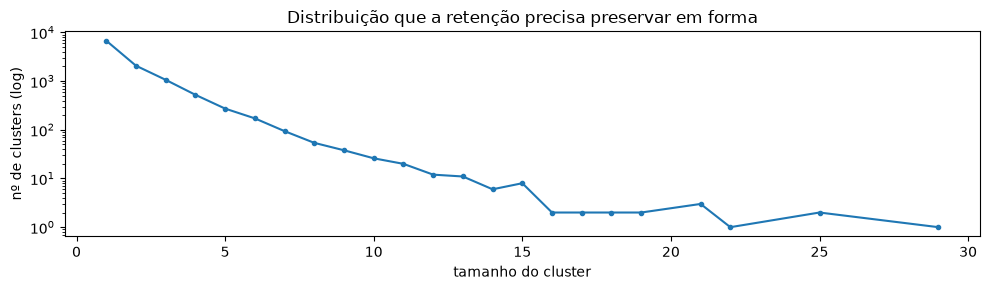

In [11]:
import matplotlib.pyplot as plt

tamanhos = corpus.groupby("cluster_id").size()
fig, ax = plt.subplots(figsize=(10, 3))
tamanhos.value_counts().sort_index().plot(ax=ax, marker="o", markersize=3, logy=True)
ax.set_xlabel("tamanho do cluster")
ax.set_ylabel("nº de clusters (log)")
ax.set_title("Distribuição que a retenção precisa preservar em forma")
plt.tight_layout()

In [18]:
ALPHA = 0.6      # 0 = colapsa para 1 por cluster; 1 = mantem tudo
PISO_TIPO = 3    # minimo por (condition, question_type), quando ha itens disponiveis

def representatividade(pos):
    """Distancia ao centroide do cluster: menor = mais representativo.

    Substitui o idxmax(tam_a), que premiava verbosidade."""
    vetores = emb_todos[pos]
    centroide = vetores.mean(axis=0)
    centroide /= np.linalg.norm(centroide) + 1e-12
    return 1 - vetores @ centroide

corpus["dist_centroide"] = np.nan
for cid, idx in corpus.groupby("cluster_id").groups.items():
    pos = corpus.index.get_indexer(idx)
    corpus.loc[idx, "dist_centroide"] = representatividade(pos)

def quantos_manter(n, alpha=ALPHA):
    return max(1, int(np.ceil(n ** alpha)))

manter_idx = []
for cid, grupo in corpus.groupby("cluster_id"):
    k = quantos_manter(len(grupo))
    manter_idx.extend(grupo.nsmallest(k, "dist_centroide").index)

retido = corpus.loc[sorted(manter_idx)].copy()
print(f"ALPHA={ALPHA}: {len(corpus):,} → {len(retido):,} linhas "
      f"({len(retido)/len(corpus):.0%} preservado)")

ALPHA=0.6: 21,340 → 17,221 linhas (81% preservado)


### Piso por tipo

O `groupby` do dedup já é por `(condition, medical_specialty, question_type)`, então
diversidade de tipo não é escolha *dentro* do cluster — é alocação global. Sem um piso,
tipos raros de pergunta desaparecem justamente nas condições com poucos itens.

In [13]:
antes_piso = len(retido)
faltantes = []

for (cond, qtype), grupo in corpus.groupby(["condition", "question_type"]):
    tem = len(retido[(retido["condition"] == cond) & (retido["question_type"] == qtype)])
    if tem < PISO_TIPO and len(grupo) > tem:
        candidatos = grupo.loc[~grupo.index.isin(retido.index)]
        faltam = min(PISO_TIPO - tem, len(candidatos))
        faltantes.extend(candidatos.nsmallest(faltam, "dist_centroide").index)

retido = pd.concat([retido, corpus.loc[faltantes]]).sort_index()
print(f"piso de tipo: +{len(retido) - antes_piso:,} linhas → {len(retido):,}")

pd.crosstab(retido["question_type"], retido["condition"].isin(
    retido["condition"].value_counts().head(5).index
)).head(10)

piso de tipo: +18 linhas → 17,239


condition,False,True
question_type,,
Anatomia e fisiologia,213,84
Diagnóstico,4562,2455
Epidemiologia,2141,858
Escolha de profissionais de saúde,234,36
Estilo de vida saudável,663,114
Outros,351,101
Tratamento,3512,1915


## Diagnóstico de condições raras

Este é o **gate** do item #8: nada é gerado ou curado à mão antes deste número existir.

A célula abaixo conta itens reais por condição e destaca as obstétricas críticas. O que
ela mede: se alguma delas ficou com suporte baixo demais, o primeiro passo **não** é
sintetizar — é verificar se havia item real que morreu no filtro de tamanho ou na
retenção, e reabilitá-lo por exceção.

In [14]:
RARAS_OBST = ["Hemorragia Pós-Parto", "Trabalho De Parto Prematuro",
              "Abortamento Incompleto", "Ameaça De Abortamento", "Gravidez Tubária"]
SUPORTE_MINIMO = 6   # abaixo disso nao da para cobrir treino + val + teste

suporte = retido["condition"].value_counts()
raras = suporte[suporte < SUPORTE_MINIMO]

print(f"{len(raras)} condições abaixo de {SUPORTE_MINIMO} itens "
      f"({len(raras)/suporte.size:.0%} das condições)\n")

print(f"{'condição':<32} {'no filtro':>10} {'pós-filtro':>11} {'retido':>7}")
for cond in RARAS_OBST:
    n_cortado = int((descartados["condition"] == cond).sum())
    n_pos_filtro = int((corpus["condition"] == cond).sum())
    n_retido = int(suporte.get(cond, 0))
    marca = "  <-- ATENÇÃO" if n_retido < SUPORTE_MINIMO else ""
    print(f"{cond:<32} {n_cortado:>10} {n_pos_filtro:>11} {n_retido:>7}{marca}")

print("\n=== Cauda longa (10 menores) ===")
print(raras.tail(10).to_string())

419 condições abaixo de 6 itens (64% das condições)

condição                          no filtro  pós-filtro  retido
Hemorragia Pós-Parto                      0          12       9
Trabalho De Parto Prematuro               3           6       6
Abortamento Incompleto                    0          12      12
Ameaça De Abortamento                     0           8       8
Gravidez Tubária                          0          11      10

=== Cauda longa (10 menores) ===
condition
Síndrome Nefrótica                   1
Cistos De Tarlov                     1
Doenças Do Nervo Vestibulococlear    1
Neuropatia Ciática                   1
Abcessos dentários                   1
Blefarofimose                        1
Estrabismo                           1
Hiperbilirrubinemia Neonatal         1
Bronquite aguda                      1
Pulmão Hipertransparente             1


In [15]:
# Recuperacao: itens reais dessas condicoes que morreram no filtro ou na retencao.
# Rodar antes de considerar curadoria manual -- sintetizar tendo item real
# descartado no caminho e o pior dos dois mundos.
criticas_baixas = [c for c in RARAS_OBST if suporte.get(c, 0) < SUPORTE_MINIMO]

if criticas_baixas:
    perdidos_filtro = descartados[descartados["condition"].isin(criticas_baixas)]
    perdidos_retencao = corpus[
        corpus["condition"].isin(criticas_baixas) & ~corpus.index.isin(retido.index)
    ]
    print(f"recuperáveis do filtro de tamanho: {len(perdidos_filtro):,}")
    print(f"recuperáveis da retenção:          {len(perdidos_retencao):,}")
    print("\nPara reabilitar por exceção, concatene o subconjunto escolhido a `retido`.")
else:
    print("Nenhuma obstétrica crítica abaixo do suporte mínimo — nada a recuperar.")

Nenhuma obstétrica crítica abaixo do suporte mínimo — nada a recuperar.


Colunas `origem` e `fonte` acompanham o corpus desde aqui: itens curados à mão no item #8
entram com `origem="curado"` e a referência do protocolo em `fonte`, o que atende também
o requisito de explainability (indicar a fonte da informação na resposta).

In [16]:
retido["origem"] = "medpt"
retido["fonte"] = "AKCIT/MedPT"

colunas = ["id", "question", "answer", "condition", "medical_specialty", "question_type",
           "cluster_id", "cluster_size", "tam_q", "tam_a", "origem", "fonte"]
final = retido[[c for c in colunas if c in retido.columns]].reset_index(drop=True)

final.to_parquet(CORPUS_CURADO, index=False)
print(f"{len(final):,} linhas | {final['condition'].nunique()} condições "
      f"| {final['cluster_id'].nunique():,} clusters")
print(f"→ {CORPUS_CURADO.name}")
final.head(3)

17,239 linhas | 651 condições | 11,186 clusters
→ corpus_curado.parquet


,id,question,answer,condition,medical_specialty,question_type,cluster_id,cluster_size,tam_q,tam_a,origem,fonte
0,1612,Meu filho apresentou bruxismo noturno e após u...,"Não, não é normal, o leve para avaliação com p...",Bruxismo,Pediatra,Diagnóstico,1471,1,160,61,medpt,AKCIT/MedPT
1,1613,Meu filho apresentou bruxismo noturno e após u...,É possível que o bruxismo diurno esteja relaci...,Bruxismo,Pediatra,Diagnóstico,1472,1,160,708,medpt,AKCIT/MedPT
2,1701,Meu bebê tem 6 meses tem 4 dentes ele fica rig...,"Sim, a primeira consulta com dentista deve ser...",Bruxismo,Pediatra,Escolha de profissionais de saúde,1473,1,104,94,medpt,AKCIT/MedPT
